# SVM Model Training

### Objective

This notebook trains and optimizes Support Vector Machine classifiers
for breast cancer detection.

The modelling workflow includes:

- Reproducing the cleaned training and test datasets
- Building a leakage-safe preprocessing and SVM pipeline
- Establishing a baseline RBF SVM
- Comparing SVM kernels
- Evaluating class-weight strategies
- Performing cross-validated hyperparameter tuning
- Selecting the final model configuration
- Training and serializing the selected model pipeline

The held-out test set will not be used for model selection or
hyperparameter tuning.

In [1]:
### Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split,StratifiedKFold,cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
### Load the dataset
df = pd.read_csv("D:/STUDY/Data_Science_Courses/PROJECTS/2.CancerGuard-SVM/CancerGuard---SVM-Cancer-Detection-API/data/Breast-Cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print("Raw dataset shape:", df.shape)

Raw dataset shape: (569, 33)


In [4]:
df_clean = df.drop(
    columns=["id", "Unnamed: 32"]
).copy()

df_clean["diagnosis"] = df_clean["diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

X shape: (569, 30)
y shape: (569,)

Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
## STRATIFIED TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining classes:")
print(y_train.value_counts().sort_index())

print("\nTest classes:")
print(y_test.value_counts().sort_index())

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)

Training classes:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test classes:
diagnosis
0    72
1    42
Name: count, dtype: int64


### Step 1 — Baseline SVM Pipeline

#### 1.1 — Create baseline pipeline

In [6]:
baseline_svm = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        )
    )
])

print(baseline_svm)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])


#### 1.2 — Define stratified 5-fold CV

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy created.")

Cross-validation strategy created.


#### 1.3 — Define evaluation metrics

In [8]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

### Step 2 — Baseline Cross-Validation

In [9]:
baseline_scores = cross_validate(
    baseline_svm,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Mean": [
        baseline_scores["test_accuracy"].mean(),
        baseline_scores["test_precision"].mean(),
        baseline_scores["test_recall"].mean(),
        baseline_scores["test_f1"].mean(),
        baseline_scores["test_roc_auc"].mean()
    ],

    "Std": [
        baseline_scores["test_accuracy"].std(),
        baseline_scores["test_precision"].std(),
        baseline_scores["test_recall"].std(),
        baseline_scores["test_f1"].std(),
        baseline_scores["test_roc_auc"].std()
    ]
})

display(baseline_results)

,Metric,Mean,Std
0,Accuracy,0.971429,0.005383
1,Precision,0.976946,0.021035
2,Recall,0.947059,0.034300
3,F1,0.960987,0.008203
4,ROC-AUC,0.994943,0.004964


### Step 3 — Compare SVM Kernels

We compare the four kernels
- linear
- rbf
- poly
- sigmoid

#### 3.1 — Define kernels

In [10]:
kernels = [
    "linear",
    "rbf",
    "poly",
    "sigmoid"
]

print("Kernels to evaluate:")
for kernel in kernels:
    print("-", kernel)

Kernels to evaluate:
- linear
- rbf
- poly
- sigmoid


#### 3.2 — Cross-validate each kernel

In [11]:
kernel_results = []

for kernel in kernels:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel=kernel,
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    kernel_results.append({
        "Kernel": kernel,
        "Accuracy_Mean": scores["test_accuracy"].mean(),
        "Precision_Mean": scores["test_precision"].mean(),
        "Recall_Mean": scores["test_recall"].mean(),
        "F1_Mean": scores["test_f1"].mean(),
        "ROC_AUC_Mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_Std": scores["test_roc_auc"].std()
    })


kernel_results_df = pd.DataFrame(kernel_results)

kernel_results_df = kernel_results_df.sort_values(
    by="ROC_AUC_Mean",
    ascending=False
).reset_index(drop=True)

display(kernel_results_df)

,Kernel,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,ROC_AUC_Std
0,rbf,0.971429,0.976946,0.947059,0.960987,0.994943,0.004964
1,linear,0.964835,0.959580,0.947059,0.952279,0.994221,0.004631
2,poly,0.901099,1.000000,0.735294,0.843592,0.992879,0.005618
3,sigmoid,0.964835,0.969496,0.935294,0.951965,0.985552,0.012910


#### 3.3 — Visual comparison

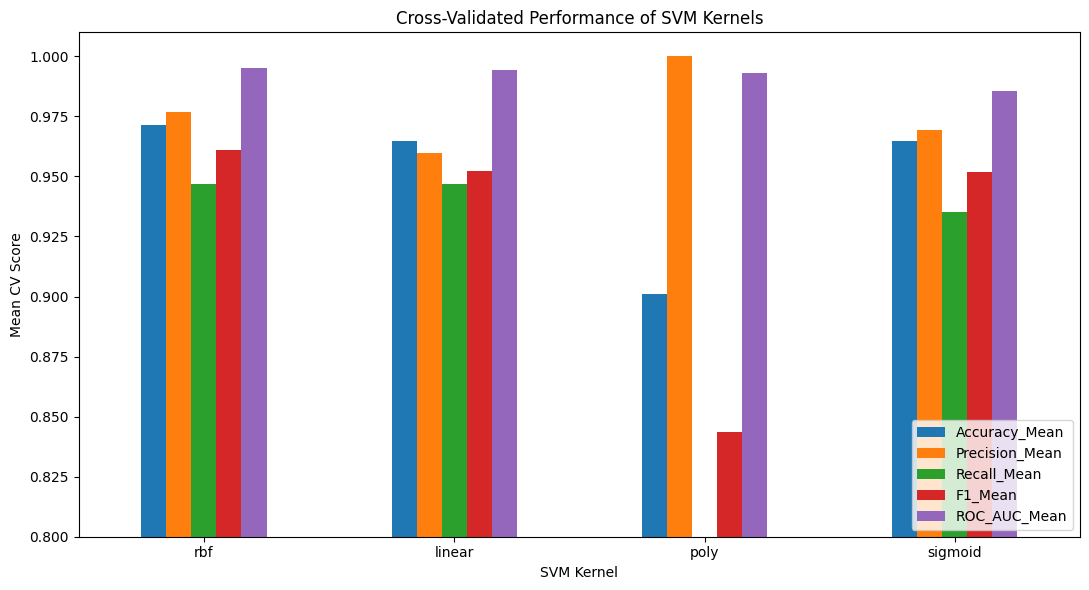

In [12]:
plot_df = kernel_results_df.set_index("Kernel")[
    ["Accuracy_Mean", "Precision_Mean",
     "Recall_Mean", "F1_Mean", "ROC_AUC_Mean"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Cross-Validated Performance of SVM Kernels")
plt.ylabel("Mean CV Score")
plt.xlabel("SVM Kernel")

plt.ylim(0.80, 1.01)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Step 4 — Class Weight Comparison

#### 4.1 — Compare class weights

In [13]:
class_weights = [
    None,
    "balanced"
]

class_weight_results = []

for weight in class_weights:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight=weight,
            probability=True,
            random_state=42
        ))
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    class_weight_results.append({
        "Class_Weight": str(weight),
        "Accuracy_Mean": scores["test_accuracy"].mean(),
        "Precision_Mean": scores["test_precision"].mean(),
        "Recall_Mean": scores["test_recall"].mean(),
        "F1_Mean": scores["test_f1"].mean(),
        "ROC_AUC_Mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_Std": scores["test_roc_auc"].std()
    })


class_weight_results_df = pd.DataFrame(
    class_weight_results
)

display(class_weight_results_df)

,Class_Weight,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,ROC_AUC_Std
0,None,0.971429,0.976946,0.947059,0.960987,0.994943,0.004964
1,balanced,0.969231,0.964624,0.952941,0.958279,0.994840,0.004317


#### 4.2 — Calculate the performance change

In [14]:
## PERFORMANCE DIFFERENCE
metrics_to_compare = [
    "Accuracy_Mean",
    "Precision_Mean",
    "Recall_Mean",
    "F1_Mean",
    "ROC_AUC_Mean"
]

comparison = pd.DataFrame({
    "Metric": metrics_to_compare,

    "Unweighted": [
        class_weight_results_df.loc[
            class_weight_results_df["Class_Weight"] == "None",
            metric
        ].iloc[0]
        for metric in metrics_to_compare
    ],

    "Balanced": [
        class_weight_results_df.loc[
            class_weight_results_df["Class_Weight"] == "balanced",
            metric
        ].iloc[0]
        for metric in metrics_to_compare
    ]
})

comparison["Difference"] = (
    comparison["Balanced"] -
    comparison["Unweighted"]
)

display(comparison)

,Metric,Unweighted,Balanced,Difference
0,Accuracy_Mean,0.971429,0.969231,-0.002198
1,Precision_Mean,0.976946,0.964624,-0.012322
2,Recall_Mean,0.947059,0.952941,0.005882
3,F1_Mean,0.960987,0.958279,-0.002708
4,ROC_AUC_Mean,0.994943,0.994840,-0.000103


### Step 5 — Hyperparameter Tuning

For RBF SVM, the key parameters are:

- C — regularization strength
- gamma — RBF kernel width
- class_weight — class weighting

#### 5.1 — Create tuning pipeline

In [15]:
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

print(svm_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])


#### 5.2 — Define parameter grid

In [16]:
param_grid = {
    "svm__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "svm__gamma": [
        "scale",
        0.001,
        0.01,
        0.1,
        1
    ],

    "svm__class_weight": [
        None,
        "balanced"
    ]
}

total_combinations = (
    len(param_grid["svm__C"])
    * len(param_grid["svm__gamma"])
    * len(param_grid["svm__class_weight"])
)

print("Parameter combinations:", total_combinations)
print("CV folds:", cv.get_n_splits())
print(
    "Approximate model fits:",
    total_combinations * cv.get_n_splits()
)

Parameter combinations: 50
CV folds: 5
Approximate model fits: 250


#### 5.3 — Configure GridSearchCV & Run Grid Search

In [17]:
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,

    scoring=scoring,
    refit="roc_auc",

    cv=cv,
    n_jobs=-1,
    verbose=1,

    return_train_score=True
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


In [19]:
grid_search.fit(
    X_train,
    y_train
)

print("\nGrid search completed.")

print("\nBest parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV ROC-AUC:",
    round(grid_search.best_score_, 6)

)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Grid search completed.

Best parameters:
{'svm__C': 100, 'svm__class_weight': None, 'svm__gamma': 0.001}

Best CV ROC-AUC: 0.995975


#### 5.4 — Create tuning-results tableCreate tuning-results table

In [20]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

tuning_results = grid_results[[
    "param_svm__C",
    "param_svm__gamma",
    "param_svm__class_weight",

    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",

    "std_test_roc_auc",
    "rank_test_roc_auc"
]].copy()

tuning_results = tuning_results.sort_values(
    by="rank_test_roc_auc"
).reset_index(drop=True)

display(
    tuning_results.head(15)
)

,param_svm__C,param_svm__gamma,param_svm__class_weight,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,100.0,0.001,NaN,0.973626,0.977460,0.952941,0.964044,0.995975,0.004310,1
1,100.0,0.001,balanced,0.973626,0.971210,0.958824,0.964423,0.995872,0.004292,2
2,10.0,0.01,balanced,0.980220,0.988889,0.958824,0.973024,0.995666,0.004713,3
3,10.0,0.01,NaN,0.975824,0.983007,0.952941,0.966858,0.995356,0.005262,4
4,1.0,scale,NaN,0.971429,0.976946,0.947059,0.960987,0.994943,0.004964,5
5,1.0,scale,balanced,0.969231,0.964624,0.952941,0.958279,0.994840,0.004317,6
6,100.0,0.01,NaN,0.969231,0.960279,0.958824,0.958789,0.994634,0.005788,7
7,1.0,0.01,balanced,0.971429,0.976450,0.947059,0.961178,0.994427,0.006635,8
8,10.0,0.001,NaN,0.964835,0.988571,0.917647,0.950819,0.994221,0.006957,9
9,1.0,0.01,NaN,0.964835,0.988571,0.917647,0.951013,0.994014,0.006653,10


#### 5.5 — Compare baseline vs tuned winner

In [21]:
best_idx = grid_search.best_index_

comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Baseline_RBF": [
        baseline_scores["test_accuracy"].mean(),
        baseline_scores["test_precision"].mean(),
        baseline_scores["test_recall"].mean(),
        baseline_scores["test_f1"].mean(),
        baseline_scores["test_roc_auc"].mean()
    ],

    "Tuned_RBF": [
        grid_results.loc[best_idx, "mean_test_accuracy"],
        grid_results.loc[best_idx, "mean_test_precision"],
        grid_results.loc[best_idx, "mean_test_recall"],
        grid_results.loc[best_idx, "mean_test_f1"],
        grid_results.loc[best_idx, "mean_test_roc_auc"]
    ]
})

comparison_df["Improvement"] = (
    comparison_df["Tuned_RBF"] -
    comparison_df["Baseline_RBF"]
)

display(comparison_df)

,Metric,Baseline_RBF,Tuned_RBF,Improvement
0,Accuracy,0.971429,0.973626,0.002198
1,Precision,0.976946,0.977460,0.000514
2,Recall,0.947059,0.952941,0.005882
3,F1,0.960987,0.964044,0.003058
4,ROC-AUC,0.994943,0.995975,0.001032


### Step 6 — Robust Final Model Selection

#### 6.1 — Examine top candidates properly

In [22]:
candidate_results = grid_results[[
    "param_svm__C",
    "param_svm__gamma",
    "param_svm__class_weight",

    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",

    "std_test_recall",
    "std_test_f1",
    "std_test_roc_auc"
]].copy()

candidate_results.columns = [
    "C",
    "Gamma",
    "Class_Weight",

    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",

    "Recall_Std",
    "F1_Std",
    "ROC_AUC_Std"
]

candidate_results = candidate_results.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

display(candidate_results.head(15))

,C,Gamma,Class_Weight,Accuracy,Precision,Recall,F1,ROC_AUC,Recall_Std,F1_Std,ROC_AUC_Std
0,100.0,0.001,NaN,0.973626,0.977460,0.952941,0.964044,0.995975,0.039896,0.016062,0.004310
1,100.0,0.001,balanced,0.973626,0.971210,0.958824,0.964423,0.995872,0.029994,0.015442,0.004292
2,10.0,0.01,balanced,0.980220,0.988889,0.958824,0.973024,0.995666,0.029994,0.011592,0.004713
3,10.0,0.01,NaN,0.975824,0.983007,0.952941,0.966858,0.995356,0.039896,0.015726,0.005262
4,1.0,scale,NaN,0.971429,0.976946,0.947059,0.960987,0.994943,0.034300,0.008203,0.004964
5,1.0,scale,balanced,0.969231,0.964624,0.952941,0.958279,0.994840,0.035294,0.015422,0.004317
6,100.0,0.01,NaN,0.969231,0.960279,0.958824,0.958789,0.994634,0.029994,0.010862,0.005788
7,1.0,0.01,balanced,0.971429,0.976450,0.947059,0.961178,0.994427,0.022010,0.011978,0.006635
8,10.0,0.001,NaN,0.964835,0.988571,0.917647,0.950819,0.994221,0.043226,0.018645,0.006957
9,1.0,0.01,NaN,0.964835,0.988571,0.917647,0.951013,0.994014,0.034300,0.012269,0.006653


#### 6.2 — Find the best models for each important metric

In [23]:
best_roc = candidate_results.loc[
    candidate_results["ROC_AUC"].idxmax()
]

best_recall = candidate_results.loc[
    candidate_results["Recall"].idxmax()
]

best_f1 = candidate_results.loc[
    candidate_results["F1"].idxmax()
]

best_accuracy = candidate_results.loc[
    candidate_results["Accuracy"].idxmax()
]

metric_winners = pd.DataFrame({
    "Best_ROC_AUC": best_roc,
    "Best_Recall": best_recall,
    "Best_F1": best_f1,
    "Best_Accuracy": best_accuracy
}).T

display(metric_winners)

,C,Gamma,Class_Weight,Accuracy,Precision,Recall,F1,ROC_AUC,Recall_Std,F1_Std,ROC_AUC_Std
Best_ROC_AUC,100.0,0.001,NaN,0.973626,0.97746,0.952941,0.964044,0.995975,0.039896,0.016062,0.00431
Best_Recall,10.0,scale,NaN,0.975824,0.971092,0.964706,0.96741,0.993498,0.028818,0.011404,0.005889
Best_F1,10.0,0.01,balanced,0.98022,0.988889,0.958824,0.973024,0.995666,0.029994,0.011592,0.004713
Best_Accuracy,10.0,0.01,balanced,0.98022,0.988889,0.958824,0.973024,0.995666,0.029994,0.011592,0.004713


#### 6.3 — Focus on near-optimal ROC-AUC models

In [24]:
best_roc_auc = candidate_results["ROC_AUC"].max()

roc_tolerance = 0.002

near_optimal = candidate_results[
    candidate_results["ROC_AUC"] >=
    (best_roc_auc - roc_tolerance)
].copy()

near_optimal = near_optimal.sort_values(
    by=["Recall", "F1", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("Best ROC-AUC:", round(best_roc_auc, 6))

print(
    "ROC-AUC acceptance threshold:",
    round(best_roc_auc - roc_tolerance, 6)
)

print(
    "Number of near-optimal models:",
    len(near_optimal)
)

display(near_optimal)

Best ROC-AUC: 0.995975
ROC-AUC acceptance threshold: 0.993975
Number of near-optimal models: 10


,C,Gamma,Class_Weight,Accuracy,Precision,Recall,F1,ROC_AUC,Recall_Std,F1_Std,ROC_AUC_Std
0,10.0,0.01,balanced,0.980220,0.988889,0.958824,0.973024,0.995666,0.029994,0.011592,0.004713
1,100.0,0.001,balanced,0.973626,0.971210,0.958824,0.964423,0.995872,0.029994,0.015442,0.004292
2,100.0,0.01,NaN,0.969231,0.960279,0.958824,0.958789,0.994634,0.029994,0.010862,0.005788
3,10.0,0.01,NaN,0.975824,0.983007,0.952941,0.966858,0.995356,0.039896,0.015726,0.005262
4,100.0,0.001,NaN,0.973626,0.977460,0.952941,0.964044,0.995975,0.039896,0.016062,0.004310
5,1.0,scale,balanced,0.969231,0.964624,0.952941,0.958279,0.994840,0.035294,0.015422,0.004317
6,1.0,0.01,balanced,0.971429,0.976450,0.947059,0.961178,0.994427,0.022010,0.011978,0.006635
7,1.0,scale,NaN,0.971429,0.976946,0.947059,0.960987,0.994943,0.034300,0.008203,0.004964
8,1.0,0.01,NaN,0.964835,0.988571,0.917647,0.951013,0.994014,0.034300,0.012269,0.006653
9,10.0,0.001,NaN,0.964835,0.988571,0.917647,0.950819,0.994221,0.043226,0.018645,0.006957


### Step 7 — Lock the Final Model Configuration

In [25]:
final_svm = Pipeline([
    ("scaler", StandardScaler()),
    
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma=0.01,
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

print("Final SVM configuration locked.")
print()
print(final_svm)

Final SVM configuration locked.

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=10, class_weight='balanced', gamma=0.01,
                     probability=True, random_state=42))])


In [26]:
final_svm.fit(X_train, y_train)

print("Final SVM fitted successfully.")
print("Training observations:", X_train.shape[0])
print("Number of features:", X_train.shape[1])

Final SVM fitted successfully.
Training observations: 455
Number of features: 30


In [27]:
### Save the final model
import joblib
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)

model_path = "../models/final_svm_pipeline.pkl"

joblib.dump(final_svm, model_path)

print("Final model saved successfully.")
print("Model path:", model_path)

Final model saved successfully.
Model path: ../models/final_svm_pipeline.pkl
